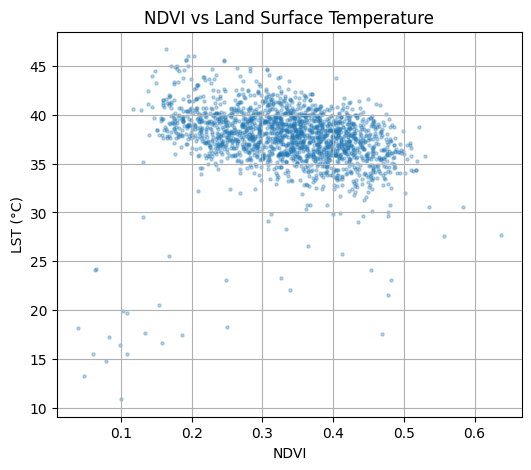

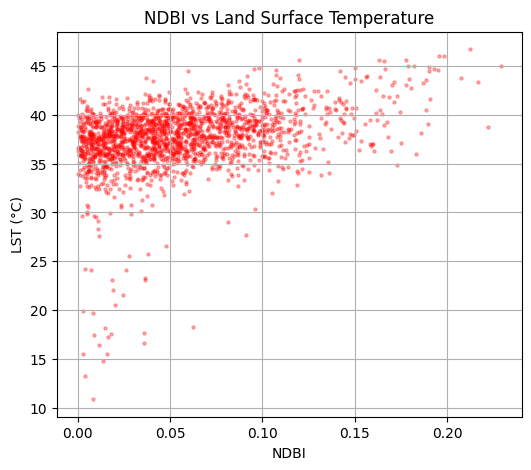

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv('/content/Kathmandu_UHI_Sample.csv')

# NDVI vs LST
plt.figure(figsize=(6,5))
plt.scatter(df['NDVI'], df['LST'], s=5, alpha=0.3)
plt.xlabel('NDVI')
plt.ylabel('LST (°C)')
plt.title('NDVI vs Land Surface Temperature')
plt.grid()
plt.savefig('fig_ndvi_lst.png', dpi=300)

# NDBI vs LST
plt.figure(figsize=(6,5))
plt.scatter(df['NDBI'], df['LST'], s=5, alpha=0.3, color='red')
plt.xlabel('NDBI')
plt.ylabel('LST (°C)')
plt.title('NDBI vs Land Surface Temperature')
plt.grid()
plt.savefig('fig_ndbi_lst.png', dpi=300)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Load data
df = pd.read_csv('/content/Kathmandu_UHI_Sample.csv')

# Function to create scatter with regression
def plot_scatter(x, y, xlabel, ylabel, title, color, filename):

    X = df[[x]].values
    Y = df[y].values

    # Fit regression
    model = LinearRegression().fit(X, Y)
    y_pred = model.predict(X)
    r2 = model.score(X, Y)

    plt.figure(figsize=(6,5))
    plt.scatter(X, Y, s=5, alpha=0.3, color=color)

    # Regression line
    plt.plot(X, y_pred, color='black', linewidth=2)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    # Add R² text
    plt.text(min(X), max(Y),
             f'$R^2 = {r2:.2f}$',
             fontsize=10,
             bbox=dict(facecolor='white', alpha=0.6))

    plt.grid()
    plt.savefig(filename, dpi=300)
    plt.close()

# NDVI vs LST
plot_scatter('NDVI', 'LST',
             'NDVI', 'LST (°C)',
             'NDVI vs Land Surface Temperature',
             'green',
             'fig_ndvi_lst_reg.png')

# NDBI vs LST
plot_scatter('NDBI', 'LST',
             'NDBI', 'LST (°C)',
             'NDBI vs Land Surface Temperature',
             'red',
             'fig_ndbi_lst_reg.png')

Final Code

In [ ]:
import pandas as pd
import statsmodels.api as sm

# Load data
df = pd.read_csv('/content/Kathmandu_UHI_Sample.csv')

# Independent variables
X = df[['NDVI', 'NDBI']]
X = sm.add_constant(X)  # add intercept

# Dependent variable
Y = df['LST']

# Fit model
model = sm.OLS(Y, X).fit()

# Print full regression summary
print(model.summary())

# Extract R²
print("Multivariate R²:", model.rsquared)

                            OLS Regression Results                            
Dep. Variable:                    LST   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     136.8
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           3.00e-56
Time:                        17:07:44   Log-Likelihood:                -4907.0
No. Observations:                1923   AIC:                             9820.
Df Residuals:                    1920   BIC:                             9837.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         35.9953      0.381     94.522      0.0

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.regplot(
    x='NDVI',
    y='LST',
    data=df,
    scatter_kws={'s':5, 'alpha':0.3, 'color':'green'},
    line_kws={'color':'black', 'linewidth':2},
    ci=95  # confidence interval
)

plt.title('NDVI vs Land Surface Temperature')
plt.xlabel('NDVI')
plt.ylabel('LST (°C)')

plt.savefig('fig_ndvi_lst_ci.png', dpi=300)
plt.close()

In [ ]:
plt.figure(figsize=(6,5))

sns.regplot(
    x='NDBI',
    y='LST',
    data=df,
    scatter_kws={'s':5, 'alpha':0.3, 'color':'red'},
    line_kws={'color':'black', 'linewidth':2},
    ci=95
)

plt.title('NDBI vs Land Surface Temperature')
plt.xlabel('NDBI')
plt.ylabel('LST (°C)')

plt.savefig('fig_ndbi_lst_ci.png', dpi=300)
plt.close()

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

def add_r2(x, y):
    model = LinearRegression().fit(x.reshape(-1,1), y)
    return model.score(x.reshape(-1,1), y)

# NDVI R²
r2_ndvi = add_r2(df['NDVI'].values, df['LST'].values)

# NDBI R²
r2_ndbi = add_r2(df['NDBI'].values, df['LST'].values)

# Example annotation
plt.figure(figsize=(6,5))
sns.regplot(x='NDVI', y='LST', data=df, ci=95)

plt.text(0.05, max(df['LST']),
         f'$R^2 = {r2_ndvi:.2f}$',
         fontsize=10,
         bbox=dict(facecolor='white', alpha=0.7))

plt.savefig('fig_ndvi_final.png', dpi=300)
plt.close()


In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['NDVI'], df['NDBI'], df['LST'], s=2)

ax.set_xlabel('NDVI')
ax.set_ylabel('NDBI')
ax.set_zlabel('LST (°C)')
ax.set_title('Multivariate Relationship: NDVI, NDBI and LST')

plt.savefig('fig_3d_relationship.png', dpi=300)
plt.close()


In [ ]:
!pip install matplotlib-scalebar
import rasterio
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import numpy as np

def add_north_arrow(ax):
    ax.annotate('N',
                xy=(0.95, 0.15),
                xytext=(0.95, 0.30),
                arrowprops=dict(facecolor='black', width=5, headwidth=15),
                ha='center', va='center',
                fontsize=12,
                xycoords=ax.transAxes)

def plot_map(filepath, title, cmap, label, output):

    with rasterio.open(filepath) as src:
        data = src.read(1)
        resolution = src.res[0]  # pixel size

    fig, ax = plt.subplots(figsize=(6,5))

    img = ax.imshow(data, cmap=cmap)

    # Colorbar
    cbar = plt.colorbar(img, ax=ax)
    cbar.set_label(label)

    # Scale bar (meters)
    scalebar = ScaleBar(resolution, "m", location='lower left')
    ax.add_artist(scalebar)

    # North arrow
    add_north_arrow(ax)

    ax.set_title(title)
    ax.axis('off')

    plt.savefig(output, dpi=300, bbox_inches='tight')
    plt.close()

# Generate maps
plot_map('LST_Map.tif',
         'Land Surface Temperature (°C)',
         'hot',
         'Temperature (°C)',
         'fig_lst_map_final.png')

plot_map('NDVI_Map.tif',
         'Normalized Difference Vegetation Index',
         'YlGn',
         'NDVI',
         'fig_ndvi_map_final.png')

plot_map('UHI_Map.tif',
         'Urban Heat Island Intensity (Z-score)',
         'coolwarm',
         'UHI',
         'fig_uhi_map_final.png')

In [ ]:
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 2, figsize=(10,10))

axes[0,0].imshow(mpimg.imread('fig_lst_map_final.png'))
axes[0,0].set_title('(a) LST')
axes[0,0].axis('off')

axes[0,1].imshow(mpimg.imread('fig_ndvi_map_final.png'))
axes[0,1].set_title('(b) NDVI')
axes[0,1].axis('off')

axes[1,0].imshow(mpimg.imread('fig_uhi_map_final.png'))
axes[1,0].set_title('(c) UHI')
axes[1,0].axis('off')

axes[1,1].imshow(mpimg.imread('fig_ndbi_lst_reg.png'))
axes[1,1].set_title('(d) NDBI–LST Regression')
axes[1,1].axis('off')

plt.tight_layout()
plt.savefig('fig_final_panel.png', dpi=300)
plt.close()


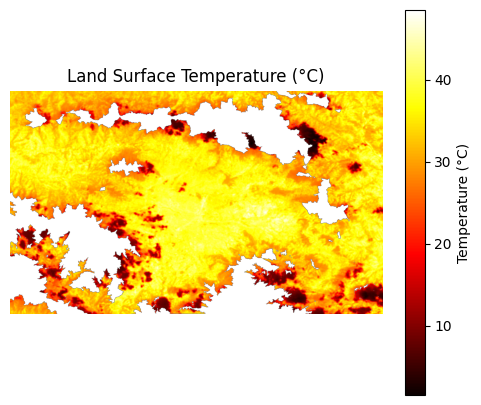

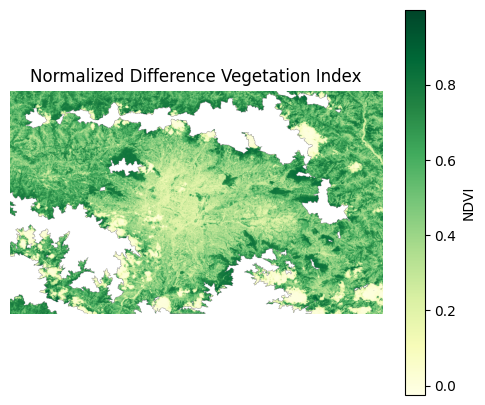

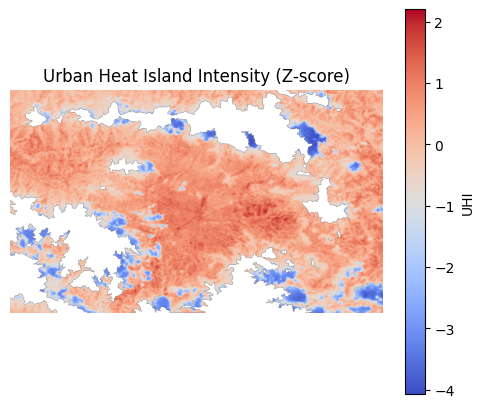

In [ ]:
import rasterio
import matplotlib.pyplot as plt

def plot_map(filepath, title, cmap, label, output):
    with rasterio.open(filepath) as src:
        data = src.read(1)

    plt.figure(figsize=(6,5))
    img = plt.imshow(data, cmap=cmap)
    plt.colorbar(label=label)
    plt.title(title)
    plt.axis('off')
    plt.savefig(output, dpi=300, bbox_inches='tight')

# LST
plot_map('LST_Map.tif',
         'Land Surface Temperature (°C)',
         'hot',
         'Temperature (°C)',
         'fig_lst_map.png')

# NDVI
plot_map('NDVI_Map.tif',
         'Normalized Difference Vegetation Index',
         'YlGn',
         'NDVI',
         'fig_ndvi_map.png')

# UHI
plot_map('UHI_Map.tif',
         'Urban Heat Island Intensity (Z-score)',
         'coolwarm',
         'UHI',
         'fig_uhi_map.png')

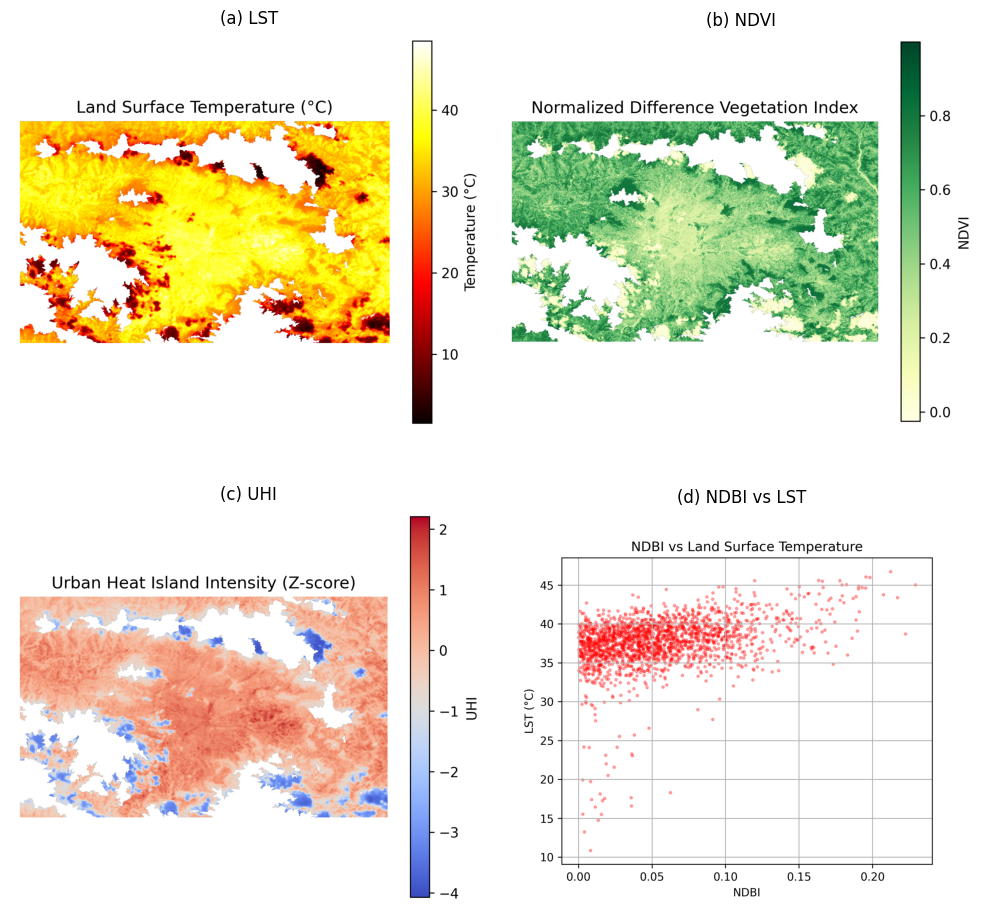

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10,10))

# Load images (saved earlier)
import matplotlib.image as mpimg

axes[0,0].imshow(mpimg.imread('fig_lst_map.png'))
axes[0,0].set_title('(a) LST')
axes[0,0].axis('off')

axes[0,1].imshow(mpimg.imread('fig_ndvi_map.png'))
axes[0,1].set_title('(b) NDVI')
axes[0,1].axis('off')

axes[1,0].imshow(mpimg.imread('fig_uhi_map.png'))
axes[1,0].set_title('(c) UHI')
axes[1,0].axis('off')

axes[1,1].imshow(mpimg.imread('fig_ndbi_lst.png'))
axes[1,1].set_title('(d) NDBI vs LST')
axes[1,1].axis('off')

plt.tight_layout()
plt.savefig('fig_multi_panel.png', dpi=300)

In [ ]:
import matplotlib.pyplot as plt
import rasterio
import pandas as pd
import seaborn as sns

# ---------------------------
# FILE PATHS (EDIT THESE)
# ---------------------------
lst_path = 'LST_Map.tif'
ndvi_path = 'NDVI_Map.tif'
uhi_path = 'UHI_Map.tif'
csv_path = 'Kathmandu_UHI_Sample.csv'

# ---------------------------
# LOAD RASTER FUNCTION
# ---------------------------
def load_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1)
    return data

# Load maps
lst = load_raster(lst_path)
ndvi = load_raster(ndvi_path)
uhi = load_raster(uhi_path)

# Load CSV
df = pd.read_csv(csv_path)

# ---------------------------
# CREATE FIGURE
# ---------------------------
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# ---------------------------
# (a) LST MAP
# ---------------------------
im1 = axes[0,0].imshow(lst, cmap='hot')
axes[0,0].set_title('(a) LST', fontsize=12)
axes[0,0].axis('off')

cbar1 = plt.colorbar(im1, ax=axes[0,0], fraction=0.046)
cbar1.set_label('Temperature (°C)')

# ---------------------------
# (b) NDVI MAP
# ---------------------------
im2 = axes[0,1].imshow(ndvi, cmap='YlGn')
axes[0,1].set_title('(b) NDVI', fontsize=12)
axes[0,1].axis('off')

cbar2 = plt.colorbar(im2, ax=axes[0,1], fraction=0.046)
cbar2.set_label('NDVI')

# ---------------------------
# (c) UHI MAP
# ---------------------------
im3 = axes[1,0].imshow(uhi, cmap='coolwarm')
axes[1,0].set_title('(c) UHI', fontsize=12)
axes[1,0].axis('off')

cbar3 = plt.colorbar(im3, ax=axes[1,0], fraction=0.046)
cbar3.set_label('UHI (Z-score)')

# ---------------------------
# (d) NDBI–LST REGRESSION
# ---------------------------
sns.regplot(
    x='NDBI',
    y='LST',
    data=df,
    ax=axes[1,1],
    scatter_kws={'s':5, 'alpha':0.3, 'color':'red'},
    line_kws={'color':'black'},
    ci=95
)

axes[1,1].set_title('(d) NDBI–LST Regression', fontsize=12)
axes[1,1].set_xlabel('NDBI')
axes[1,1].set_ylabel('LST (°C)')

# Add R² manually
from sklearn.linear_model import LinearRegression
import numpy as np

X = df['NDBI'].values.reshape(-1,1)
Y = df['LST'].values

model = LinearRegression().fit(X, Y)
r2 = model.score(X, Y)

axes[1,1].text(
    0.02, max(Y),
    f'$R^2 = {r2:.2f}$',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.7)
)

# ---------------------------
# FINALIZE AND SAVE
# ---------------------------
plt.tight_layout()
plt.savefig('Figure1_MultiPanel.png', dpi=300, bbox_inches='tight')
plt.close()

print("✅ Figure 1 saved as Figure1_MultiPanel.png")

✅ Figure 1 saved as Figure1_MultiPanel.png


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# ---------------------------
# LOAD DATA
# ---------------------------
df = pd.read_csv('Kathmandu_UHI_Sample.csv')

# Function to calculate R²
def calculate_r2(x, y):
    model = LinearRegression().fit(x.reshape(-1,1), y)
    return model.score(x.reshape(-1,1), y)

# ---------------------------
# FIGURE WITH 2 SCATTER PLOTS
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# ============================
# (a) NDVI vs LST
# ============================
sns.regplot(
    x='NDVI',
    y='LST',
    data=df,
    ax=axes[0],
    scatter_kws={'s':5, 'alpha':0.3, 'color':'green'},
    line_kws={'color':'black', 'linewidth':2},
    ci=95
)

# R² calculation
r2_ndvi_lst = calculate_r2(df['NDVI'].values, df['LST'].values)

axes[0].set_title('(a) NDVI–LST', fontsize=12)
axes[0].set_xlabel('NDVI')
axes[0].set_ylabel('LST (°C)')

axes[0].text(
    df['NDVI'].min(),
    df['LST'].max(),
    f'$R^2 = {r2_ndvi_lst:.2f}$',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8)
)

# ============================
# (b) NDVI vs UHI
# ============================
sns.regplot(
    x='NDVI',
    y='UHI',
    data=df,
    ax=axes[1],
    scatter_kws={'s':5, 'alpha':0.3, 'color':'blue'},
    line_kws={'color':'black', 'linewidth':2},
    ci=95
)

# R² calculation
r2_ndvi_uhi = calculate_r2(df['NDVI'].values, df['UHI'].values)

axes[1].set_title('(b) NDVI–UHI', fontsize=12)
axes[1].set_xlabel('NDVI')
axes[1].set_ylabel('UHI (Z-score)')

axes[1].text(
    df['NDVI'].min(),
    df['UHI'].max(),
    f'$R^2 = {r2_ndvi_uhi:.2f}$',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8)
)

# ---------------------------
# SAVE FIGURE
# ---------------------------
plt.tight_layout()
plt.savefig('Figure2_NDVI_Scatter.png', dpi=300, bbox_inches='tight')
plt.close()

print("✅ Figure 2 (NDVI scatter plots) saved successfully")

✅ Figure 2 (NDVI scatter plots) saved successfully


Study Area

In [ ]:
pip install geopandas contextily

In [ ]:
import geopandas as gpd

world = gpd.read_file('/content/ne_10m_admin_0_countries_nep.shp')

nepal = world[world['NAME'] == 'Nepal']

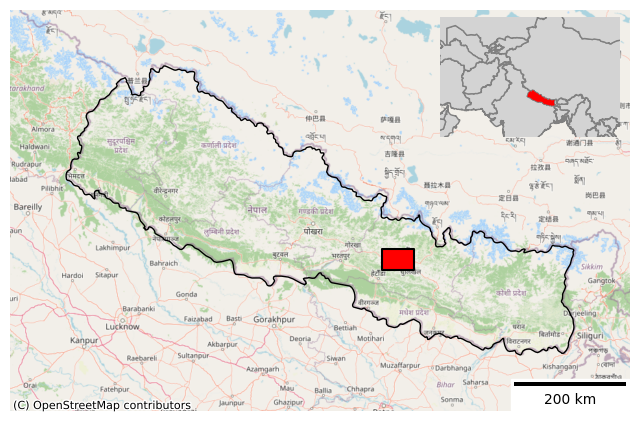

✅ Advanced study area map created successfully


In [ ]:
# ================================
# INSTALL (run once in Colab)
# ================================
!pip install geopandas contextily matplotlib-scalebar

# ================================
# IMPORT LIBRARIES
# ================================
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import box
from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ================================
# LOAD DATA
# ================================
world = gpd.read_file('/content/ne_10m_admin_0_countries_nep.shp')

# Filter Nepal
nepal = world[world['NAME'] == 'Nepal']

# ================================
# CREATE GEE ROI (KATHMANDU)
# ================================
roi_geom = box(85.1, 27.55, 85.6, 27.85)
kathmandu = gpd.GeoDataFrame({'geometry':[roi_geom]}, crs="EPSG:4326")

# ================================
# REPROJECT
# ================================
world = world.to_crs(epsg=3857)
nepal = nepal.to_crs(epsg=3857)
kathmandu = kathmandu.to_crs(epsg=3857)

# ================================
# CREATE MAIN FIGURE
# ================================
fig, ax = plt.subplots(1, 1, figsize=(8,8))

# Plot Nepal boundary
nepal.plot(ax=ax, color='none', edgecolor='black', linewidth=1)

# Plot Kathmandu
kathmandu.plot(ax=ax, color='red', edgecolor='black', linewidth=1.5)

# ================================
# HILLSHADE / TERRAIN BASEMAP
# ================================
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik  # Using OpenStreetMap as an alternative
)

# ================================
# NORTH ARROW (TOP RIGHT)
# ================================
ax.annotate('N',
            xy=(0.93, 0.75),
            xytext=(0.93, 0.90),
            arrowprops=dict(facecolor='black', width=4, headwidth=12),
            ha='center',
            va='center',
            fontsize=14,
            xycoords=ax.transAxes)

# ================================
# SCALE BAR
# ================================
scalebar = ScaleBar(1, units="m", location='lower right')
ax.add_artist(scalebar)

# ================================
# INSET MAP (SOUTH ASIA)
# ================================
axins = inset_axes(ax, width="30%", height="30%", loc='upper right')

# Plot South Asia (subset world)
xmin, ymin, xmax, ymax = world.total_bounds
world.plot(ax=axins, color='lightgray', edgecolor='gray')

# Highlight Nepal
nepal.plot(ax=axins, color='red')

# Clean inset
axins.set_xlim(6000000, 12000000)   # adjust if needed
axins.set_ylim(2000000, 6000000)
#axins.set_title("South Asia", fontsize=8)
axins.axis('off')

# ================================
# ZOOM MAIN MAP TO NEPAL
# ================================
ax.set_xlim(nepal.total_bounds[0]-100000, nepal.total_bounds[2]+100000)
ax.set_ylim(nepal.total_bounds[1]-100000, nepal.total_bounds[3]+100000)

# ================================
# FINAL SETTINGS
# ================================
#ax.set_title('Study Area: Kathmandu Valley, Nepal', fontsize=14)
ax.axis('off')

# Save
plt.savefig('/content/Figure_Study_Area_Final.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Advanced study area map created successfully")